# Arbol de Decision y Bosque Aleatorio
Marlon Solano C.

## Parte 1: Arbol de Decision (Decision Tree)

In [43]:
import pandas as nd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection  import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


In [10]:
mydata = load_iris()
x = mydata.data #data de entrada
y = mydata.target #data de salida
print(x.shape)
print(y.shape)



(150, 4)
(150,)


In [4]:
mydata.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
mydata.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [15]:
# Generemos una triple particion de lo datos, para entrenamiento, validacion y prueba (60,30,30)


from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 1. Cargamos los datos primero
mydata = load_iris()
X = mydata.data
y = mydata.target

# 2. Hacemos la partición (ahora sí X e y ya existen)
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=.2, shuffle=True, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=.25, shuffle=True, random_state=1)

print("¡Partición exitosa!")
print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de validación:', X_val.shape)
print('Tamaño del conjunto de prueba', X_test.shape)



¡Partición exitosa!
Tamaño del conjunto de entrenamiento: (90, 4)
Tamaño del conjunto de validación: (30, 4)
Tamaño del conjunto de prueba (30, 4)


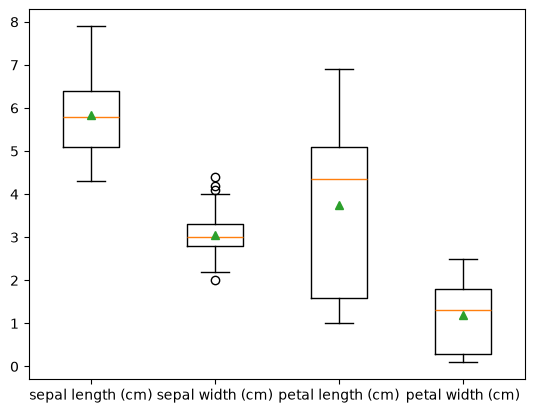

In [21]:
plt.boxplot(x, showmeans=True)
plt.xticks(range(1, len(mydata.feature_names) + 1), mydata.feature_names)
plt.show()

In [26]:
## Generemos un arbol deSede decision
modelDT = DecisionTreeClassifier() #Inicializamos con los hiperparametros determinados
clf = modelDT.fit(X_train, y_train) #Entrenamos elModelo modelo con los datos de entrenamiento
# observamos el desempeno
print('Exactitud en el conjunto de entrenamiento:', clf.score(X_train, y_train))


Exactitud en el conjunto de entrenamiento: 1.0


In [27]:
predicciones = clf.predict(X_val) # Realizamos predicciones sobre el conjunto de validación

print('Exactitud en el conjunto de validación:', clf.score(X_val, y_val))

Exactitud en el conjunto de validación: 0.9666666666666667


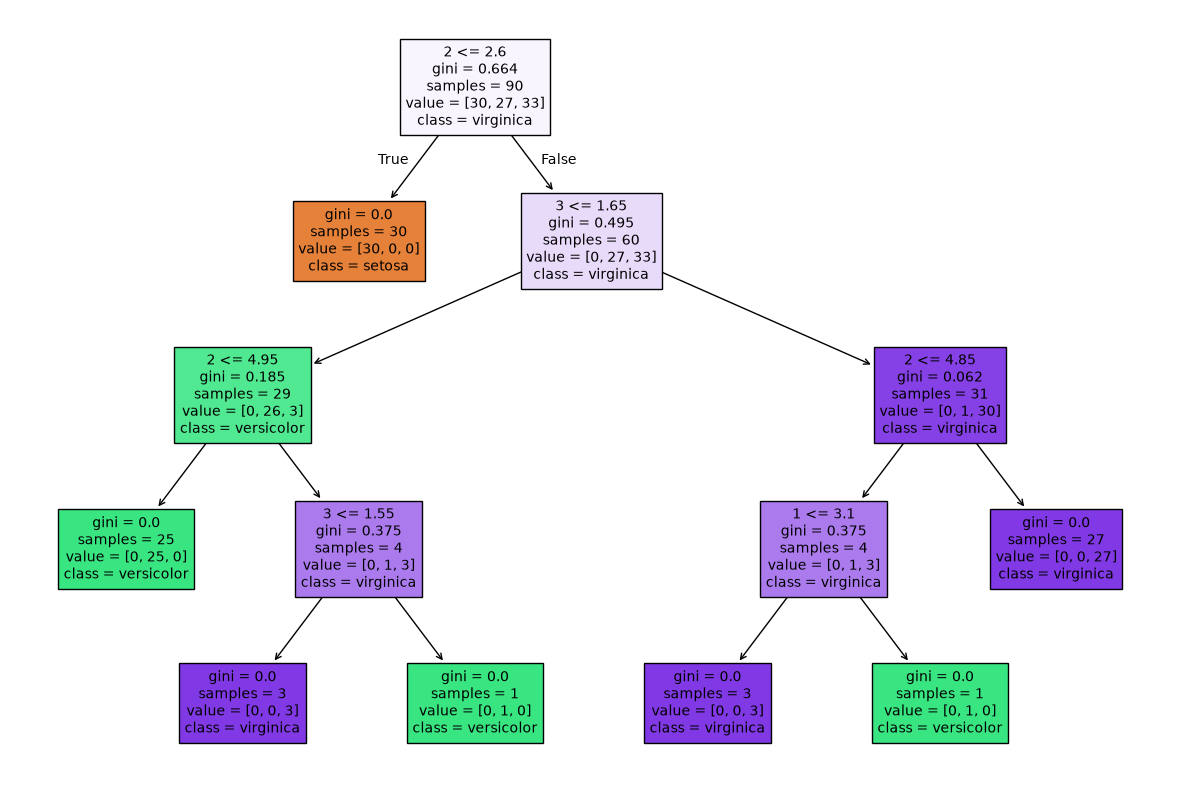

In [31]:
# Para realizar un grafo de Decision Tree
from sklearn import tree
# 1. Configurar el tamaño de la imagen
plt.figure(figsize=(15, 10))
# 2. Dibujar el árbol directamente
tree.plot_tree(decision_tree=clf,
              max_depth=None,
              feature_names=list(pd.DataFrame(X_train).columns.astype(str)),
              class_names=[str(c) for c in mydata.target_names],
              filled=True,
              proportion=False,
              fontsize=10)
# 3. Mostrar la imagen en Jupyter
plt.show()


## Parte 2: Random Forest (Bosque Aleatorio)

In [32]:
from sklearn.ensemble import RandomForestClassifier
import sklearn.datasets

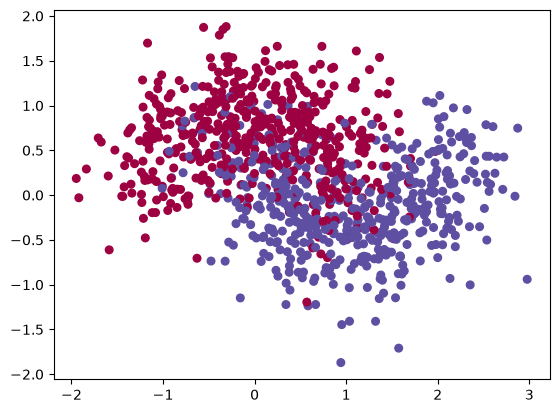

In [35]:
N = 1000 # Total de datos
noisy_data = sklearn.datasets.make_moons(n_samples=N, noise=0.4, random_state=17) # Generamos datos con ruido
X, Y = noisy_data # Separamos los datos de entrada y salida

plt.scatter(X[:, 0], X[:, 1], c=Y, s=30, cmap=plt.cm.Spectral) # Graficamos los datos

In [36]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=.4, shuffle=True, random_state=17)

mimodelo = RandomForestClassifier()

clf = mimodelo.fit(Xtrain, Ytrain)

results = clf.predict(Xtest)

confusion_matrix(Ytest, results)

array([[165,  37],
       [ 32, 166]])

In [37]:
clf.score(Xtest, Ytest)

0.8275

In [38]:
clf.feature_importances_

array([0.4520342, 0.5479658])

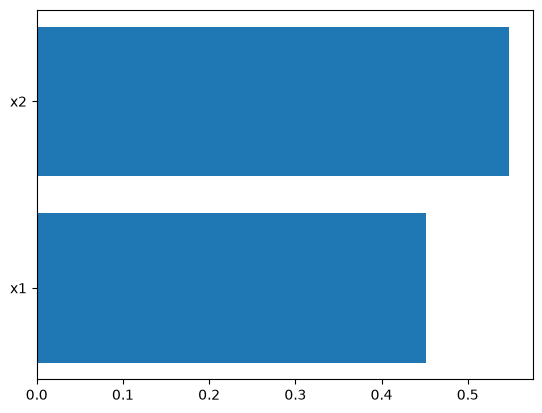

In [39]:
plt.barh(['x1', 'x2'], width=clf.feature_importances_);

In [40]:
## Algunos de lo hiperparámetros del clasificador bosque aleatorio:
mimodelo2 = RandomForestClassifier(n_estimators=10,  # número de árboles en el Forest y después promedia por votación.
                                  criterion='gini',   # métrica para determinar las ramas. También puede ser: 'entropy', para la GananciaDeInformación (IG).
                                  max_depth=2, # Depth=k : máximo 2^k líneas/ramas.       
                                  min_samples_split = 6,  # mínimo de puntos muestrales requeridos en un nodo para hacer la ramificación. Puede ser fracción de 0 a 1.
                                  min_samples_leaf = 4,  # mínimo de puntos muestrales que deben quedar en cada nueva ramificación (hojas). Puede ser fracción de 0 a 1.
                                  #max_features= 'auto',   # número de características (features) que se consideran en cada ramificación: auto=sqrt(n_features).
                                  max_leaf_nodes=16,  # solo nos quedamos con las mejores k hojas.
                                  bootstrap=True,  # Cada Árbol se muestrea seleccionando la cantidad de datos del conjunto de entrenamiento, pero con reemplazo. False:los datos usados en cada árbol simpre es el mismo, el Train-set.
                                  oob_score=True,  # en caso de utilizar Out-of-bag samples.
                                  verbose=0,     # tipo de despliega de información durante el entrenamiento.
                                  n_jobs=-1,    # total de hilos a usar en las rutinas paralelizables: "-1" :usar todos los posibles.
                                  max_samples=None,   # Cuando se usa Boostrap, es el total de datos de Xtrain a usar en cada árbol. "None" usará Xtrain[0].
                                  random_state=19)


In [41]:
clf2 = mimodelo2.fit(Xtrain, Ytrain)
clf2.score(Xtest, Ytest)

C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


0.855